In [11]:
import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe
import site_archive_nci
from pyearthtools.data.time import Petdt
from pyearthtools.pipeline.operations.xarray.join import GeospatialTimeSeriesMerge
import xarray as xr
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pyearthtools.training
import pyearthtools.training as training
import warnings
warnings.filterwarnings("ignore", message="Can't initialize NVML")
import site_archive_nci
import pyearthtools.pipeline as petpipe

# Parent Classes

In [2]:
# Copyright Commonwealth of Australia, Bureau of Meteorology 2024.
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

from __future__ import annotations

from abc import ABCMeta, abstractmethod

from pyearthtools.utils.initialisation import InitialisationRecordingMixin
from pyearthtools.pipeline import Pipeline

from pyearthtools.training.data import PipelineDataModule


class SimpleModel(InitialisationRecordingMixin, metaclass=ABCMeta):
    """
    The SimpleModel base wrapper removes assumptions from the primary model wrapper class.
    This provides a simpler on-ramp for early-stage model development, without imposing
    as many requirements on the developer for comprehensive functionality.

    It also allows the direct use of a single Pipeline, without requiring a
    train/validate split to be defined, avoiding the need for a PipelineDataModule.

    New users may wish to start here before implementing the full ModelWrapper class.
    """

    def __init__(
        self,
    ):
        """
        Construct Base model wrapper

        `model` will not be recorded in the initialisation by default, set `_record_model` to change
        this behaviour.
        """

        pass

    @abstractmethod
    def fit(self, pipeline, epochs=1):
        """
        Perform a single epoch 'fit' operation based on walking the pipeline
        """
        pass

    @abstractmethod
    def predict(self, pipeline, query=None):
        """
        Perform a single prediction based either on a pipeline or a single sample
        """


class ModelWrapper(InitialisationRecordingMixin, metaclass=ABCMeta):
    """
    Base Model Wrapper

    Defines the interface in which to use a `model`, and `datamodule/Pipeline`
    """

    _default_datamodule: type[PipelineDataModule] = PipelineDataModule
    _record_model: bool = False

    def __init__(
        self,
        model,
        data: (
            dict[str, Pipeline | str | tuple[Pipeline, ...]]
            | tuple[Pipeline | str, ...]
            | str
            | Pipeline
            | PipelineDataModule
        ),
    ):
        """
        Construct Base model wrapper

        `model` will not be recorded in the initialisation by default, set `_record_model` to change
        this behaviour.

        Args:
            model (Any):
                Model to use.
            data (dict[str, Pipeline | tuple[Pipeline, ...]] | tuple[Pipeline, ...] | Pipeline | PipelineDataModule):
                Data to use. If not `PipelineDataModule` will be made into `_default_datamodule`.
                Will only then have `get_sample`.
        """
        super().__init__()
        self.record_initialisation(ignore="model" if self._record_model else None)

        if not isinstance(data, PipelineDataModule):
            data = self._default_datamodule(data)
        if not isinstance(data, self._default_datamodule):
            data = self._default_datamodule(data.pipelines, train_split=data._train_split, valid_split=data._valid_split)  # type: ignore

        self.model = model
        self.datamodule = data

    def get_sample(self, idx, *, fake_batch_dim: bool = False):
        """Get sample from the `datamodule`."""
        return self.datamodule.get_sample(idx, fake_batch_dim=fake_batch_dim)

    @property
    def pipelines(self):
        """Get pipelines from the `datamodule`."""
        return self.datamodule.pipelines

    @property
    def splits(self):
        """Training and Validation split as configured by the `datamodule`."""
        return {"training": self.datamodule._train_split, "validation": self.datamodule._valid_split}

    @abstractmethod
    def load(self, *args, **kwargs):
        """Load model"""

    @abstractmethod
    def save(self, *args, **kwargs):
        """Save model"""

    @abstractmethod
    def predict(self, data, *args, **kwargs):
        """
        Run a forward pass with the model

        Args:
            data:
                Data to run prediction with
        """

In [3]:
class PassthroughModel(SimpleModel):
    '''
    The purpose of this class it is to connect the PyEarthTools pipeline structure
    to an underlying set of ML model weights for inference. The term 'model' here
    gets a bit ambiguous, so we will call the underlying model the 'raw model' and the
    PyEarthTools model the 'simple model'.
    
    A trainable model provides:
      - A fit method implementing the training process
      - A predict method to perform a prediction with the model
      - The ability to get a single sample of the input data

    This skips the following expectations of a fully-defined model:
      - A way to load and save model weights    
      - The ability to get the pipeline required by the model
      - The ability to get the train/validate split data pipelines
      - Callbacks for validation, verification, or tracking training convergence
    '''

    def fit(self, pipeline, epochs=1):
        # The pass through model needs no weights or real model, but we need to implement
        # abstract method anyway as training is assumed by the class
        pass

    def predict(self, pipeline, query=None):
        '''
        If no query is provided, a prediction will be made to each step in the pipeline
        '''

        if query:
            model_inputs = pipeline[query]
            return model_inputs
            # yield self.raw_model.predict(model_inputs)

        else:
            raise Exception("This model supports single-sample inference only")



# SimpleModel Class (Autoencoder Version 1:1 input:output)

In [4]:
class SimpleModel(PassthroughModel, nn.Module):
    def __init__(self, input_dims, layers, height, width):

        def computeOutput(dim, kernel_size, stride, padding):
            out = (dim + 2 * padding - (kernel_size - 1) - 1) / stride + 1
            return int(out)
       

        nn.Module.__init__(self)
        PassthroughModel.__init__(self)

        self.input_dims = input_dims
        self.channels = [input_dims]
        self.width = width
        self.height = height
        spatial_dims = [(height, width)]

        for i in range(1, layers + 1):
            self.channels.append(16 * i)

        encoder_layers = []
        num_pairs = len(self.channels) - 1

        for _ in range(num_pairs):
            prev_h, prev_w = spatial_dims[-1]
            new_h = computeOutput(prev_h, 4, 2, 1)
            new_w = computeOutput(prev_w, 4, 2, 1)
            spatial_dims.append((new_h, new_w))

        for i in range(num_pairs):
            chan_in = self.channels[i]
            chan_out = self.channels[i + 1]
            encoder_layers.append(nn.Conv2d(chan_in, chan_out, kernel_size=4, stride=2, padding=1))
            if i < num_pairs - 1:
                encoder_layers.append(nn.ReLU())
        self.encoder = nn.Sequential(*encoder_layers)

        reversed_channels = self.channels[::-1]
        reversed_sd = spatial_dims[::-1]

        decoder_layers = []
        for i in range(num_pairs):
            chan_in = reversed_channels[i]
            chan_out = reversed_channels[i + 1]

            in_h, in_w = reversed_sd[i]
            out_h, out_w = reversed_sd[i + 1]

            base_h = (in_h - 1) * 2 - 2 * 1 + 4
            base_w = (in_w - 1) * 2 - 2 * 1 + 4 #Formula to find the output hxw after convTranspose2d
            output_padding = (out_h - base_h, out_w - base_w) #set padding to account for the difference between the ouput size we are expecting and the output of the convolution.

            decoder_layers.append(
                nn.ConvTranspose2d(chan_in, chan_out, kernel_size=4, stride=2,
                                    padding=1, output_padding=output_padding)
            )
            if i < num_pairs - 1:
                decoder_layers.append(nn.ReLU())

        decoder_layers.append(nn.Sigmoid())
        self.decoder = nn.Sequential(*decoder_layers)
        self.optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        self.criterion = nn.MSELoss()


    def forward(self, x):      
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

    def fit(self, pipeline, epochs):
        batch_size= 1
        max_samples= 500
        print_per= 500
        device='cpu'
        sample_ix = 0

        for epoch in range (epochs):
            print(f'current epoch {epoch+1}')
            total_loss = 0    
            epoch_samples = 0
            iterator = iter(pipeline)
            
            while True:
                try:
                    sample = next(iterator)
                except StopIteration:
                    print('stop')
                    break  # advance the epoch loop
                except:
                    print('error - general')
                    continue # some samples are just missing
        
                sample_ix += batch_size
                epoch_samples += batch_size
                
                if epoch_samples % print_per == 0:
                    print(epoch_samples)
                
                if sample_ix > max_samples:
                    print('exceeded max samples')
                    break
    
        
                x = torch.from_numpy(sample).float().to(device)   
                
                if torch.any(torch.isnan(x)):
                    continue

                self.optimizer.zero_grad()
                y = self.forward(x)
                loss = self.criterion(y, x)
                loss.backward()
                self.optimizer.step()
                total_loss += loss.item()
    
            if epoch_samples != 0:
                avg_loss = total_loss / epoch_samples
                print(f'Epoch [{epoch+1}/{epochs}], Average Loss: {avg_loss:.4f}')
            else:
                print('no samples processed this epoch')
    def predict(self, pipeline):
        pet_iterator = iter(pipeline)
        sample_numpy = next(pet_iterator)
        sample_gpu = torch.from_numpy(sample_numpy).float().to('cpu')
        prediction_gpu = model.forward(sample_gpu)
        prediction_cpu = prediction_gpu.to('cpu').detach().numpy()
        return prediction_cpu

    def plot_results(self, pipeline):
        pet_iterator = iter(pipeline)
        fig1 = plt.figure('results', figsize=(24,12))
        for ix1 in range(3):
            sample_numpy = next(pet_iterator)
            sample_gpu = torch.from_numpy(sample_numpy).float().to('cpu')
            prediction_gpu = model.forward(sample_gpu)
            prediction_cpu = prediction_gpu.to('cpu').detach().numpy()
            ax1 = fig1.add_subplot(3,3,(ix1*3)+1)
            ax1.imshow(sample_numpy[0,0])
            ax1.set_title('Sample')
            ax1 = fig1.add_subplot(3,3,(ix1*3)+2)
            ax1.imshow(prediction_cpu[0,0])
            ax1.set_title('Prediction')
            ax1 = fig1.add_subplot(3,3,(ix1*3)+3)
            ax1.imshow(prediction_cpu[0,0] - sample_numpy[0,0])    
            ax1.set_title('Difference: Prediction - Sample')

# EXAMPLE USAGE

In [ ]:
himawari = petdata.archive.Himawari('surface_global_irradiance')
satpipe = petpipe.Pipeline(
    himawari
)
fullsat = petpipe.Pipeline(
    satpipe,
    petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),  # 
    # Align the data variable's coordinate order to the dataset coordinate order so all arrays are the same shape
    petpipe.operations.xarray.AlignDataVariableDimensionsToDatasetCoords(),  
    petdata.transform.region.Bounding(-35, -25, 138, 150),  # cut down on region for example
    petpipe.operations.xarray.normalisation.SingleValueDivision(1200),
    petpipe.operations.xarray.conversion.ToNumpy(),
    petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
    iterator=petpipe.iterators.DateRange('20200101T00', '20200301T00', interval='10 minutes'),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError
)
fullsat_validate = petpipe.Pipeline(
    satpipe,
    petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),  # 
    # Align the data variable's coordinate order to the dataset coordinate order so all arrays are the same shape
    petpipe.operations.xarray.AlignDataVariableDimensionsToDatasetCoords(),  
    petdata.transform.region.Bounding(-35, -25, 138, 150),  # cut down on region for example
    petpipe.operations.xarray.normalisation.SingleValueDivision(1200),
    petpipe.operations.xarray.conversion.ToNumpy(),
    petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
    iterator=petpipe.iterators.DateRange('20210101T00', '20220101T00', interval='10 minutes'),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError
)

In [ ]:
model = SimpleModel(input_dims = 1, layers = 3, height = 501, width =  601)

In [ ]:
model.fit(pipeline = fullsat , epochs = 1)

In [ ]:
model.predict(pipeline = fullsat_validate)

In [ ]:
model.plot_results(pipeline = fullsat_validate)

# EXAMPLE 2 (Very Basic Pipeline W/ no Normalisation)

In [27]:
var_names=["2t"]    
var = pyearthtools.data.archive.ERA5(var_names)

data  = petpipe.Pipeline(
    var,
    petpipe.operations.xarray.conversion.ToNumpy(),
    petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
    iterator=petpipe.iterators.DateRange('20210101T00', '20210102T00', interval='6 hours'),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError
)

In [28]:
model = SimpleModel(input_dims = 1, layers = 3, height = 721, width =  1440)

In [29]:
model.fit(pipeline = data , epochs = 1)

current epoch 1
stop
Epoch [1/1], Average Loss: 77138.6641


In [32]:
model.predict(pipeline = data)

array([[[[0.6128711 , 0.5414689 , 0.784523  , ..., 0.65599096,
          0.6819314 , 0.45797783],
         [0.6451951 , 0.66280353, 0.7095865 , ..., 0.97210217,
          0.9945667 , 0.767827  ],
         [0.5968036 , 0.8221906 , 0.97427213, ..., 0.32110962,
          0.94071484, 0.53812927],
         ...,
         [0.7141586 , 0.4402778 , 0.697557  , ..., 0.56870973,
          0.3997496 , 0.6883251 ],
         [0.5300031 , 0.8603923 , 0.36448982, ..., 0.41966012,
          0.6757018 , 0.56530595],
         [0.525746  , 0.32029366, 0.44580096, ..., 0.5621774 ,
          0.5525047 , 0.5179241 ]]]],
      shape=(1, 1, 721, 1440), dtype=float32)

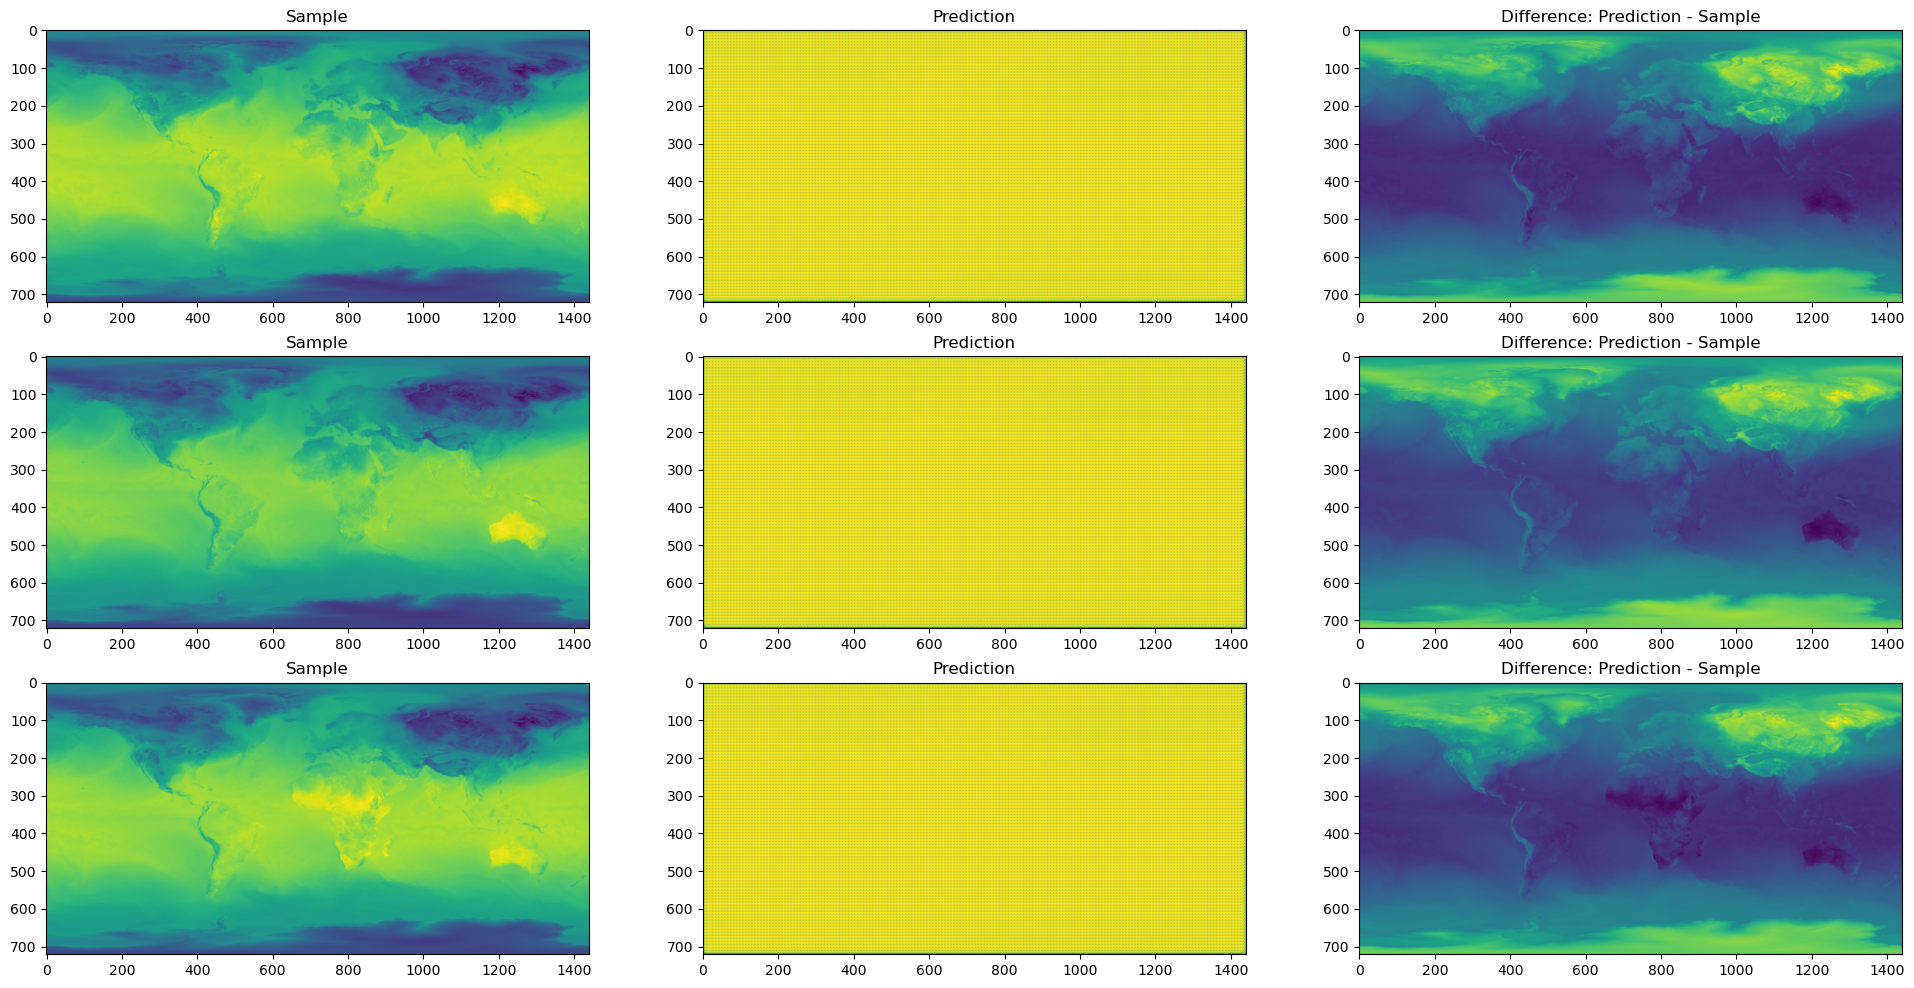

In [33]:
model.plot_results(pipeline = data)